Generating synthetic data for Preservation Score parity...

          RUNNING REFERENCE FRAMEWORK (SciPy)
-> SciPy Weighted Preservation Score: 8.560377
-> SciPy Unweighted Preservation Score: 8.539381

          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy Weighted Preservation Score: 8.560377
-> DimRedPy Unweighted Preservation Score: 8.539381

          PARITY VALIDATION
1. MSE on Weighted Score   : 1.391551e-27
2. MSE on Unweighted Score : 0.000000e+00

SUCCESS: DimRedPy Preservation Score perfectly matches rigorous SciPy reference.
Saved comparison plot to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_analysis\verify_parity_analysis_preservation_score_plot.png


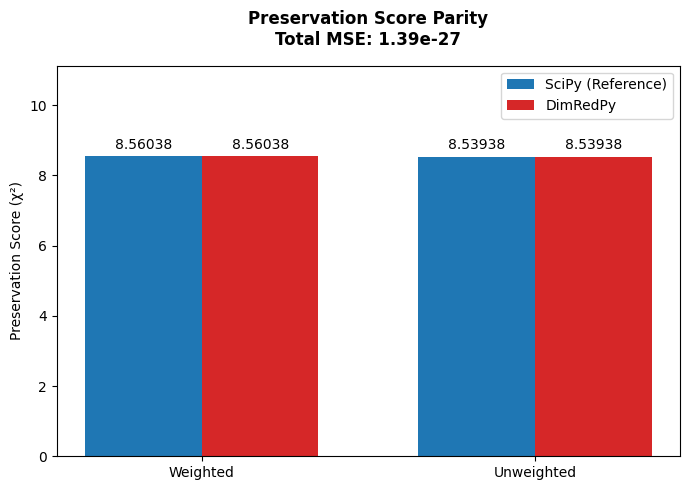

In [1]:
"""
Rigorous Verification of Analysis Parity: Preservation Score (Stress)
"""

import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from dimredpy.shared.analysis import preservation_score

# ---------------------------------------------------------------------------
# 1. Generate Synthetic Data
# ---------------------------------------------------------------------------
print("Generating synthetic data for Preservation Score parity...")
np.random.seed(42)
N = 400
# High-dimensional data
landmarks_hd = np.random.randn(N, 10)
# Low-dimensional data
landmarks_ld = np.random.randn(N, 2)
# Random weights
weights = np.random.uniform(0.5, 1.5, size=N)

# ---------------------------------------------------------------------------
# 2. Run Reference Framework (SciPy exact pdist & nested loops)
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (SciPy)")
print("=======================================================")

# Exact upper-triangle distances using SciPy
ref_hd_dist = pdist(landmarks_hd, metric='euclidean')
ref_ld_dist = pdist(landmarks_ld, metric='euclidean')

# Exact stress calculation
# χ² = Sum (w_i * w_j * (D_HD_ij - D_LD_ij)^2) / Sum (w_i * w_j)
ref_stress_sum = 0.0
ref_weight_sum = 0.0
idx = 0

for i in range(N):
    for j in range(i + 1, N):
        w_ij = weights[i] * weights[j]
        diff_sq = (ref_hd_dist[idx] - ref_ld_dist[idx]) ** 2
        ref_stress_sum += w_ij * diff_sq
        ref_weight_sum += w_ij
        idx += 1

ref_score_weighted = ref_stress_sum / ref_weight_sum
ref_score_unweighted = np.mean((ref_hd_dist - ref_ld_dist) ** 2)

print(f"-> SciPy Weighted Preservation Score: {ref_score_weighted:.6f}")
print(f"-> SciPy Unweighted Preservation Score: {ref_score_unweighted:.6f}")

# ---------------------------------------------------------------------------
# 3. Run DimRedPy Framework
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

dimred_score_weighted = preservation_score(landmarks_hd, landmarks_ld, weights=weights)
dimred_score_unweighted = preservation_score(landmarks_hd, landmarks_ld, weights=None)

print(f"-> DimRedPy Weighted Preservation Score: {dimred_score_weighted:.6f}")
print(f"-> DimRedPy Unweighted Preservation Score: {dimred_score_unweighted:.6f}")

# ---------------------------------------------------------------------------
# 4. Parity Validation
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

mse_weighted = (ref_score_weighted - dimred_score_weighted) ** 2
mse_unweighted = (ref_score_unweighted - dimred_score_unweighted) ** 2

print(f"1. MSE on Weighted Score   : {mse_weighted:.6e}")
print(f"2. MSE on Unweighted Score : {mse_unweighted:.6e}")

total_mse = mse_weighted + mse_unweighted

if total_mse < 1e-10:
    print("\nSUCCESS: DimRedPy Preservation Score perfectly matches rigorous SciPy reference.")
else:
    print("\nFAILURE: Statistical divergence detected in preservation score parity.")

# ---------------------------------------------------------------------------
# 5. Visual Verification
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')

labels = ['Weighted', 'Unweighted']
ref_vals = [ref_score_weighted, ref_score_unweighted]
dimred_vals = [dimred_score_weighted, dimred_score_unweighted]

x = np.arange(len(labels))
width = 0.35

ax.bar(x - width/2, ref_vals, width, label='SciPy (Reference)', color='#1f77b4')
ax.bar(x + width/2, dimred_vals, width, label='DimRedPy', color='#d62728')

ax.set_ylabel("Preservation Score (χ²)")
ax.set_title(f"Preservation Score Parity\nTotal MSE: {total_mse:.2e}", fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, max(max(ref_vals), max(dimred_vals)) * 1.3)

for i in range(len(labels)):
    ax.annotate(f'{ref_vals[i]:.5f}', xy=(x[i] - width/2, ref_vals[i]),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)
    ax.annotate(f'{dimred_vals[i]:.5f}', xy=(x[i] + width/2, dimred_vals[i]),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plot_path = os.path.join(script_dir, "verify_parity_analysis_preservation_score_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Saved comparison plot to {plot_path}")
